In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [166]:
# --- 1. Загрузка исторических данных ---

name = "1BackTestData"
filename = f"data/{name}.csv"
data = pd.read_csv(filename, parse_dates=['timestamp'])
data.set_index('timestamp', inplace=True)

In [39]:
# --- 2. Простая стратегия: скользящая средняя ---

short_window = 200
long_window = 50

data['SMA200'] = data['close'].rolling(window=short_window).mean()
data['SMA50'] = data['close'].rolling(window=long_window).mean()

# Сигналы: 1 = покупка, -1 = продажа, 0 = держать
data['signal'] = 0
data.loc[data['SMA200'] > data['SMA50'], 'signal'] = 1
data.loc[data['SMA200'] < data['SMA50'], 'signal'] = -1

In [167]:
# --- 3. Бэктестинг с частичными позициями и контролем открытых сделок ---

initial_cash = 1000 # стартовый капитал
cash = initial_cash # свободные деньги (зафиксированы)
investments = 0 # деньги в активах (могут меняться)
positions = []  # список открытых позиций (цена покупки)
portfolio_values = [initial_cash]
trade_log = []

commission = 0.000  # 0.1% комиссия
#trade_fraction = 0.1  # 10% от портфеля на одну сделку
trade_amount = 100 # фикс сумма на сделку

for i in range(1, len(data)):
    price = data['open'].iloc[i]
    signal = data['signal'].iloc[i - 1]

    # --- Покупка ---
    if signal == 1 and cash >= trade_amount:
        #trade_amount = cash * trade_fraction
        position_size = trade_amount / price
        cash -= trade_amount + trade_amount * commission
        positions.append({'size': position_size, 'price': price, 'investments': investments})
        investments = sum([p['size'] * price for p in positions])
        portfolio_value = cash + investments
        trade_log.append({'date': data.index[i], 'type': 'buy', 'position_size': position_size, 'price': price, 'investments': investments,
                          'cash': cash, 'portfolio': portfolio_value, 'Pnl': 0})

    # --- Продажа (закрываем только одну позицию) ---
    elif signal == -1 and len(positions) > 0:
        pos = positions.pop(0)  # FIFO — закрываем первую открытую сделку
        PnL = pos['size'] * price - pos['size'] * pos['price']
        cash += pos['size'] * price
        cash -= pos['size'] * price * commission
        investments = sum([p['size'] * price for p in positions])
        portfolio_value = cash + investments
        trade_log.append({'date': data.index[i], 'type': 'sell', 'position_size': pos['size'], 'price': price, 'investments': investments,
                          'cash': cash, 'portfolio': portfolio_value, 'Pnl': PnL})

    # Текущая стоимость портфеля = наличные + все открытые позиции по текущей цене
    portfolio_value = cash + sum([p['size'] * price for p in positions])
    portfolio_values.append(portfolio_value)

data['portfolio'] = portfolio_values
data['open_positions'] = [len(positions) for _ in range(len(data))]


In [168]:
trade_log_df = pd.DataFrame(trade_log)
trade_log_df

,date,type,position_size,price,investments,cash,portfolio,Pnl
0,2025-03-11 23:00:00,buy,10.0,10,100.0,900.0,1000.0,0.0
1,2025-03-12 00:00:00,buy,5.0,20,300.0,800.0,1100.0,0.0
2,2025-03-12 01:00:00,sell,10.0,25,125.0,1050.0,1175.0,150.0
3,2025-03-12 02:00:00,sell,5.0,5,0.0,1075.0,1075.0,-75.0
4,2025-03-12 03:00:00,buy,100.0,1,100.0,975.0,1075.0,0.0
5,2025-03-12 04:00:00,buy,10.0,10,1100.0,875.0,1975.0,0.0
6,2025-03-12 05:00:00,sell,100.0,20,200.0,2875.0,3075.0,1900.0
7,2025-03-12 06:00:00,sell,10.0,5,0.0,2925.0,2925.0,-50.0


In [172]:
filename = f"logs/{name}_trade_log.csv"
trade_log_df.to_csv(filename, index=False)
print(f"\nДанные сохранены в файл: {filename}")


Данные сохранены в файл: logs/1BackTestData_trade_log.csv


In [162]:
# --- 4. Анализ результатов ---

# Подсчёт прибыльных и убыточных сделок
profits = []
for i in range(0, len(trade_log_df)-1, 2):
    buy = trade_log_df.iloc[i]['price']
    sell = trade_log_df.iloc[i + 1]['price']
    profits.append(sell - buy)
profits = np.array(profits)
num_trades = len(profits)
num_wins = np.sum(profits > 0)
win_rate = num_wins / num_trades * 100 if num_trades > 0 else 0

# Максимальная просадка
portfolio_array = np.array(portfolio_values)
running_max = np.maximum.accumulate(portfolio_array)
drawdown = (running_max - portfolio_array) / running_max
max_drawdown = np.max(drawdown) * 100

total_return = (portfolio_values[-1] - initial_cash) / initial_cash * 100

In [163]:
# --- 5. Вывод статистики ---
print(f"Общая доходность: {total_return:.2f}%")
print(f"Количество сделок: {num_trades}")
print(f"Процент прибыльных сделок: {win_rate:.2f}%")
print(f"Максимальная просадка: {max_drawdown:.2f}%")

Общая доходность: 192.50%
Количество сделок: 4
Процент прибыльных сделок: 50.00%
Максимальная просадка: 8.51%


In [ ]:
# --- 4. Анализ результатов (для частичных позиций) ---
trade_df = pd.DataFrame(trade_log)

profits = []
closed_trades = []

open_trades = []

for _, row in trade_df.iterrows():
    if row['type'] == 'buy':
        open_trades.append(row['price'])

    elif row['type'] == 'sell' and len(open_trades) > 0:
        buy_price = open_trades.pop(0)  # FIFO
        sell_price = row['price']
        profit = sell_price - buy_price
        profits.append(profit)

        closed_trades.append({
            'buy_price': buy_price,
            'sell_price': sell_price,
            'profit': profit
        })

profits = np.array(profits)

# --- Метрики ---
num_trades = len(profits)
num_wins = np.sum(profits > 0)
num_losses = np.sum(profits <= 0)

win_rate = (num_wins / num_trades * 100) if num_trades > 0 else 0

avg_profit = profits.mean() if num_trades > 0 else 0
avg_win = profits[profits > 0].mean() if num_wins > 0 else 0
avg_loss = profits[profits <= 0].mean() if num_losses > 0 else 0

profit_factor = abs(profits[profits > 0].sum() / profits[profits <= 0].sum()) if num_losses > 0 else np.inf

# --- Максимальная просадка ---
portfolio_array = np.array(portfolio_values)
running_max = np.maximum.accumulate(portfolio_array)
drawdown = (running_max - portfolio_array) / running_max
max_drawdown = np.max(drawdown) * 100

# --- Доходность ---
total_return = (portfolio_values[-1] - initial_cash) / initial_cash * 100

# --- 5. Вывод ---
print(f"Общая доходность: {total_return:.2f}%")
print(f"Количество закрытых сделок: {num_trades}")
print(f"Win rate: {win_rate:.2f}%")
print(f"Средняя прибыль на сделку: {avg_profit:.5f}")
print(f"Средний выигрыш: {avg_win:.5f}")
print(f"Средний убыток: {avg_loss:.5f}")
print(f"Profit factor: {profit_factor:.2f}")
print(f"Максимальная просадка: {max_drawdown:.2f}%")


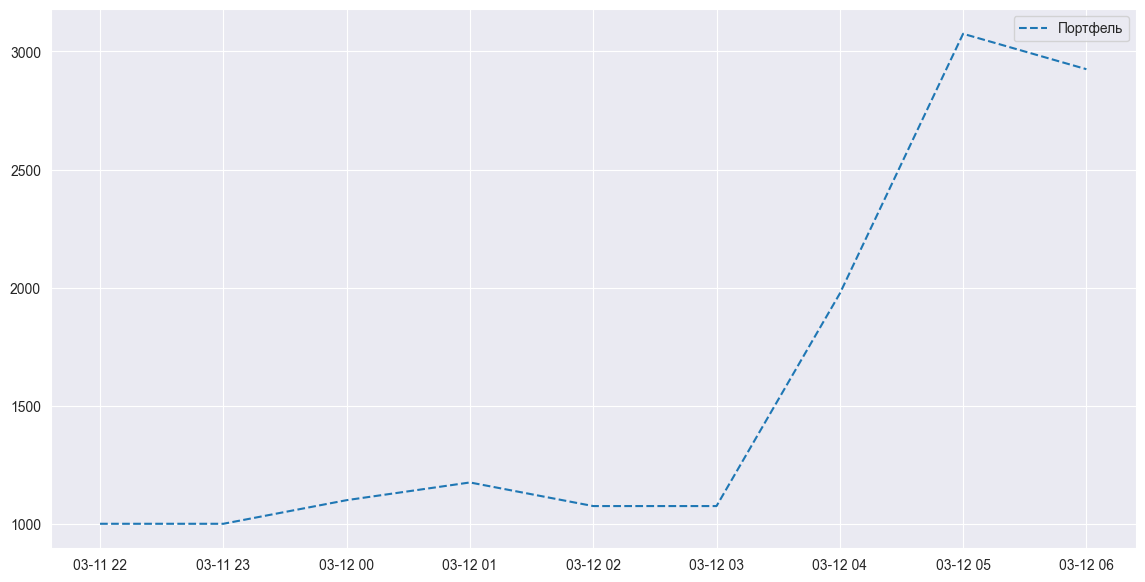

In [164]:
# --- 6. График ---
plt.figure(figsize=(14,7))
plt.plot(data.index, data['portfolio'], label='Портфель', linestyle='--')
plt.legend()
plt.show()